Explore the two data centres - class distribution, demographics, etc.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, fisher_exact

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

CLASS_NAMES = {
    0: "No pathology",
    1: "Tessellated fundus",
    2: "Diffuse CRA",
    3: "Patchy CRA",
    4: "Macular atrophy",
}

In [3]:
DATA_ROOT = "/Users/mosfiratnasreen/Documents/25/UCL/Applied AI for MI/cw2/Data"

TRAIN_CSV = os.path.join(DATA_ROOT, "Training", "Training_LabelsDemographic.csv")
TEST_CSV  = os.path.join(DATA_ROOT, "Testing", "Testing_LabelDemographic.csv")

df = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)

print(f"Train: {len(df)},  Test: {len(df_test)}")
print(f"Columns: {list(df.columns)}")
df.head()

Train: 1143,  Test: 248
Columns: ['image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight', 'data_center']


,image,myopic_maculopathy_grade,age,sex,height,weight,data_center
0,mmac_task_1_train_0001.png,0,51,male,183.5,78.9,1
1,mmac_task_1_train_0002.png,0,51,male,183.5,78.9,1
2,mmac_task_1_train_0003.png,0,50,male,184.5,81.7,1
3,mmac_task_1_train_0004.png,0,50,male,184.5,81.7,1
4,mmac_task_1_train_0005.png,0,49,male,184.5,82.2,1


note - 1,143 training / 248 test samples with 7 columns including 'data_center'

In [4]:
print("Dtypes:\n", df.dtypes)
print("\nUnique values per column:")
for col in df.columns:
    n = df[col].nunique()
    print(f"  {col}: {n} unique", end="")
    if n <= 10:
        print(f"  -> {sorted(df[col].dropna().unique())}")
    else:
        print()

Dtypes:
 image                        object
myopic_maculopathy_grade      int64
age                           int64
sex                          object
height                      float64
weight                      float64
data_center                   int64
dtype: object

Unique values per column:
  image: 1143 unique
  myopic_maculopathy_grade: 5 unique  -> [0, 1, 2, 3, 4]
  age: 62 unique
  sex: 2 unique  -> ['female', 'male']
  height: 140 unique
  weight: 290 unique
  data_center: 2 unique  -> [1, 2]


note - all columns clean — data_center is integer-coded (1 or 2), sex has 2 values, no surprises in dtypes.

In [5]:
COL_GRADE  = "myopic_maculopathy_grade" 
COL_IMAGE  = "image"                      
COL_AGE    = "age"                         
COL_SEX    = "sex"                         
COL_CENTRE = "data_center"                      

print(f"Unique centres: {df[COL_CENTRE].unique()}")
print(f"Centre counts:\n{df[COL_CENTRE].value_counts()}")

Unique centres: [1 2]
Centre counts:
data_center
1    990
2    153
Name: count, dtype: int64


note - severe site imbalance — centre 1 has 990 samples (87%) vs centre 2 with only 153 (13%).

do the two centres have the same distribution of maculopathy grades?

In [6]:
ct_raw = pd.crosstab(df[COL_CENTRE], df[COL_GRADE])
ct_norm = pd.crosstab(df[COL_CENTRE], df[COL_GRADE], normalize="index")

print("Absolute counts:")
print(pd.crosstab(df[COL_CENTRE], df[COL_GRADE], margins=True))
print("\nRow-normalised (proportions per centre):")
print(ct_norm.round(3))

Absolute counts:
myopic_maculopathy_grade    0    1    2   3   4   All
data_center                                          
1                         366  379  187  37  21   990
2                          38   33   37  23  22   153
All                       404  412  224  60  43  1143

Row-normalised (proportions per centre):
myopic_maculopathy_grade      0      1      2      3      4
data_center                                                
1                         0.370  0.383  0.189  0.037  0.021
2                         0.248  0.216  0.242  0.150  0.144


note - grade distribution differs — centre 1 is 75% grades 0–1, while centre 2 has 6× more severe cases (grades 3–4)

In [7]:
# Chi-squared test of independence: grade vs centre
chi2, p_chi2, dof, expected = chi2_contingency(ct_raw)
print(f"Chi-squared = {chi2:.2f},  p = {p_chi2:.4e},  dof = {dof}")
print("=> Significant association" if p_chi2 < 0.05 else "=> Not significant")

Chi-squared = 102.82,  p = 2.4652e-21,  dof = 4
=> Significant association


note - Chi-squared confirms this is not chance

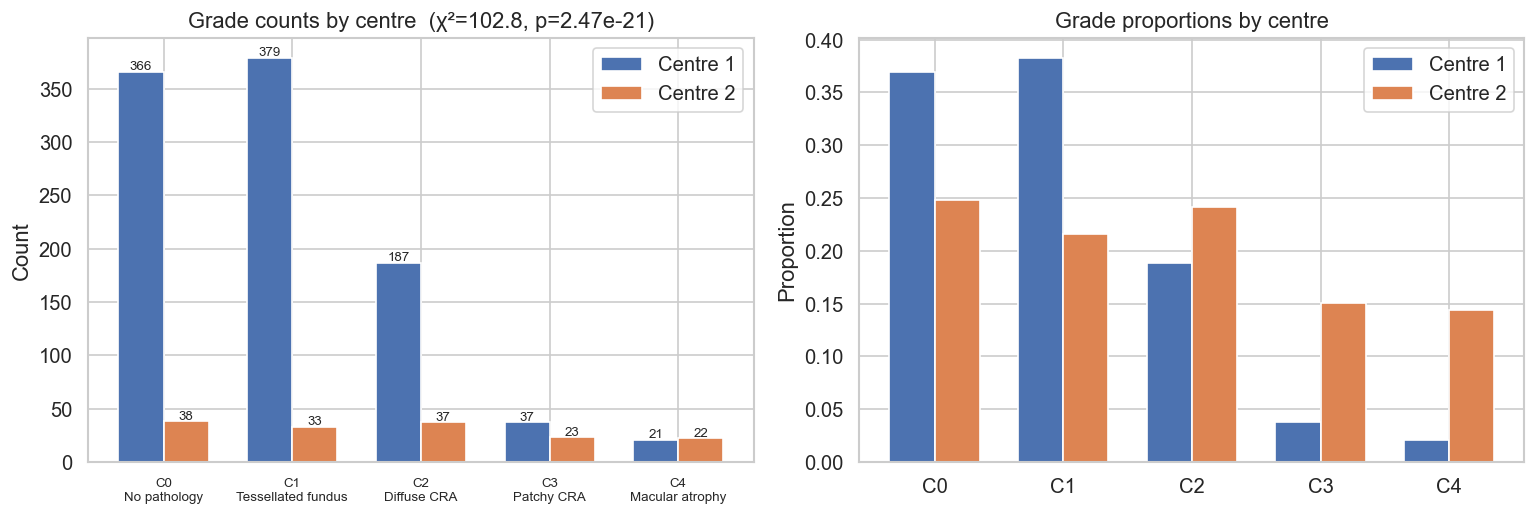

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

centres = sorted(df[COL_CENTRE].unique())
x = np.arange(5)
w = 0.35

for i, c in enumerate(centres):
    counts_c = ct_raw.loc[c].reindex(range(5), fill_value=0)
    bars = axes[0].bar(x + i * w, counts_c.values, w, label=f"Centre {c}")
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                     str(int(bar.get_height())), ha="center", fontsize=8)

axes[0].set_xticks(x + w/2)
axes[0].set_xticklabels([f"C{i}\n{CLASS_NAMES[i]}" for i in range(5)], fontsize=8)
axes[0].set_ylabel("Count")
axes[0].set_title(f"Grade counts by centre  (χ²={chi2:.1f}, p={p_chi2:.2e})")
axes[0].legend()

for i, c in enumerate(centres):
    props = ct_norm.loc[c].reindex(range(5), fill_value=0)
    axes[1].bar(x + i * w, props.values, w, label=f"Centre {c}")
axes[1].set_xticks(x + w/2)
axes[1].set_xticklabels([f"C{i}" for i in range(5)])
axes[1].set_ylabel("Proportion")
axes[1].set_title("Grade proportions by centre")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_grade_by_centre.png", dpi=150, bbox_inches="tight")
plt.show()

^^^ bar charts showing the grade distribution gap visually.

In [9]:
# Age summary + Mann-Whitney U
print("Age summary per centre:")
print(df.groupby(COL_CENTRE)[COL_AGE].describe().round(1))

groups = [g[COL_AGE].dropna() for _, g in df.groupby(COL_CENTRE)]
if len(groups) == 2:
    stat, p_age = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    print(f"\nMann-Whitney U: stat={stat:.0f}, p={p_age:.4e}")
    print("=> Significant" if p_age < 0.05 else "=> Not significant")

Age summary per centre:
             count  mean   std   min   25%   50%   75%   max
data_center                                                 
1            990.0  52.2   9.2  30.0  46.0  52.0  58.0  88.0
2            153.0  64.4  12.4  29.0  57.0  64.0  73.0  93.0

Mann-Whitney U: stat=30823, p=2.8940e-32
=> Significant


note - centre 2 patients are ~12 years older on average (64.4 vs 52.2)

In [10]:
# Sex distribution + Fisher exact
sex_ct = pd.crosstab(df[COL_CENTRE], df[COL_SEX])
print("Sex counts by centre:")
print(sex_ct)

if sex_ct.shape == (2, 2):
    odds, p_sex = fisher_exact(sex_ct)
    print(f"Fisher exact: OR={odds:.2f}, p={p_sex:.4e}")
else:
    chi2_s, p_sex, _, _ = chi2_contingency(sex_ct)
    print(f"Chi-squared: {chi2_s:.2f}, p={p_sex:.4e}")

Sex counts by centre:
sex          female  male
data_center              
1               293   697
Chi-squared: 0.00, p=1.0000e+00


In [11]:
print(df.groupby(COL_CENTRE)[COL_SEX].apply(lambda x: x.isna().sum()))

data_center
1      0
2    153
Name: sex, dtype: int64


note - centre 2 has entirely missing sex data, making the chi-squared meaningless.

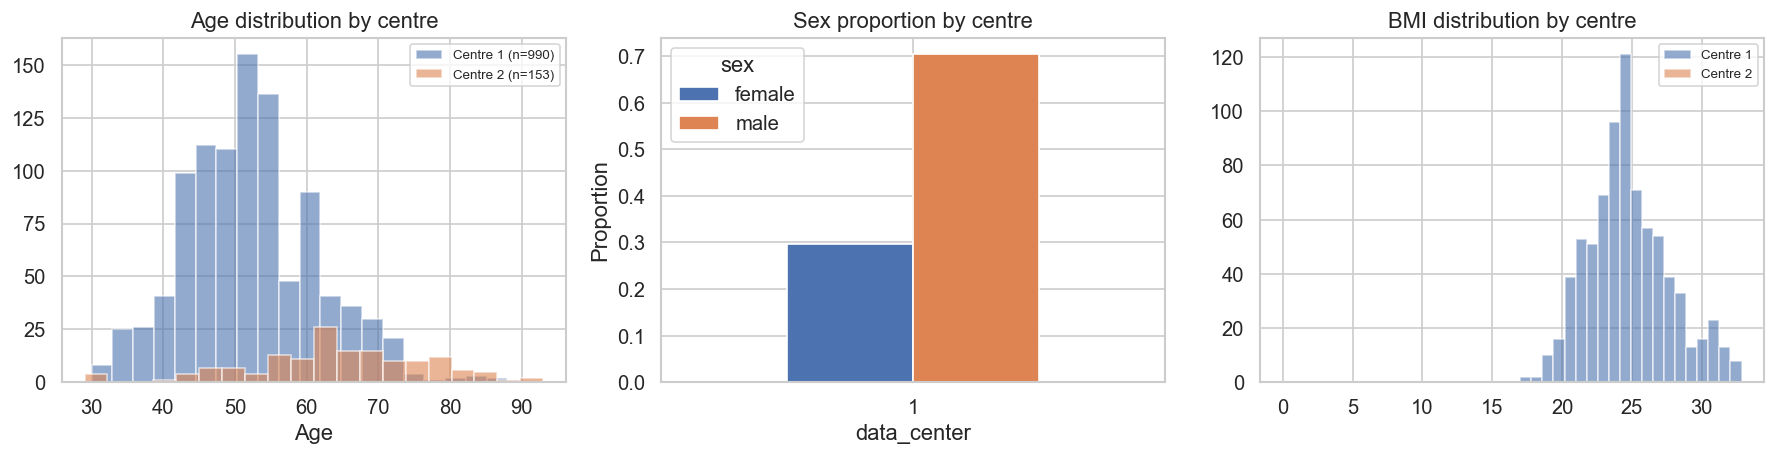

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age
for c in centres:
    subset = df[df[COL_CENTRE] == c][COL_AGE].dropna()
    axes[0].hist(subset, alpha=0.6, bins=20, label=f"Centre {c} (n={len(subset)})")
axes[0].set_title("Age distribution by centre")
axes[0].set_xlabel("Age")
axes[0].legend(fontsize=8)

# Sex proportions
sex_norm = pd.crosstab(df[COL_CENTRE], df[COL_SEX], normalize="index")
sex_norm.plot.bar(ax=axes[1], rot=0)
axes[1].set_title("Sex proportion by centre")
axes[1].set_ylabel("Proportion")

# BMI if available
if "height" in df.columns and "weight" in df.columns:
    df["bmi"] = df["weight"] / (df["height"] / 100) ** 2
    for c in centres:
        subset = df[df[COL_CENTRE] == c]["bmi"].dropna()
        axes[2].hist(subset, alpha=0.6, bins=20, label=f"Centre {c}")
    axes[2].set_title("BMI distribution by centre")
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, "No height/weight columns", ha="center", va="center",
                 transform=axes[2].transAxes, fontsize=11, color="grey")
    axes[2].set_title("BMI (not available)")

plt.tight_layout()
plt.savefig("fig_demographics_by_centre.png", dpi=150, bbox_inches="tight")
plt.show()

^ Age/sex/BMI demographic distributions by centre

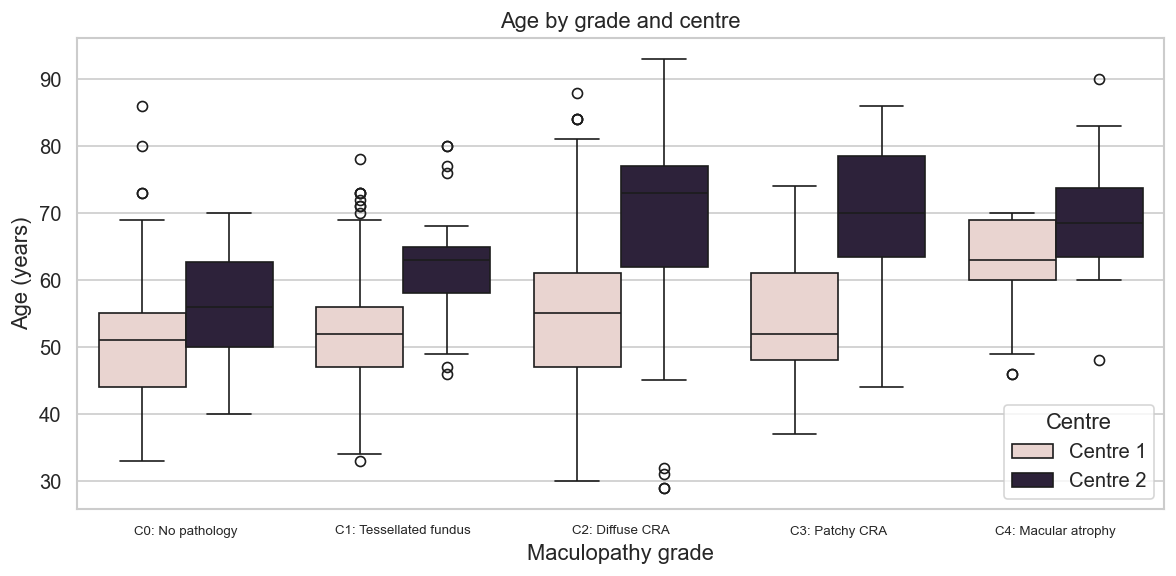

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x=COL_GRADE, y=COL_AGE, hue=COL_CENTRE, ax=ax)
ax.set_xticks(range(5))
ax.set_xticklabels([f"C{i}: {CLASS_NAMES[i]}" for i in range(5)], fontsize=8)
ax.set_xlabel("Maculopathy grade")
ax.set_ylabel("Age (years)")
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Centre 1", "Centre 2"], title="Centre")
ax.set_title("Age by grade and centre")
plt.tight_layout()
plt.savefig("fig_age_grade_centre.png", dpi=150, bbox_inches="tight")
plt.show()

^ Age × grade × centre boxplot showing the confounding